<a href="https://colab.research.google.com/github/DajahV/Simple_Linear_Regression/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Project Assignment

In [1]:
file_path = '/content/drive/MyDrive/DHF 3mtt Projects/Simple Linear Regression/advertisement_data.csv'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Importing libraries that will be used for this projects

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [4]:
#Reading the advertisement dataset into a dataframe called df

df = pd.read_csv(file_path)

In [8]:
# reading the first 10 rows of the dataframe

df.head(10)

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
5,29.0,9.614382,1.027163,105.889148
6,55.0,24.893811,4.273602,198.679825
7,31.0,17.355042,2.289855,108.733932
8,76.0,24.648898,7.130116,270.189400
9,13.0,0.431128,2.229423,48.280582


In [9]:
# reading the last 10 rows of the dataframe

df.tail(10)

,TV,Radio,Social_Media,Sales
4562,54.0,26.077597,3.808179,188.723202
4563,93.0,25.285149,2.805840,327.466288
4564,99.0,36.024174,4.288755,355.807121
4565,19.0,1.490192,1.485684,66.393800
4566,16.0,2.339222,0.563121,52.423800
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411
4571,42.0,15.966688,5.046548,148.202414


In [10]:
# descriptive statistics and transposes of the datasets

df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [11]:
# checking the concise technical summary of a Pandas DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [12]:
# check for missing data
df.isna().sum()

,0
TV,10
Radio,4
Social_Media,6
Sales,6


In [13]:
# removing rows with missing data

df = df.dropna()

In [14]:
# rechecking the data for missing data

df.isna().sum()

,0
TV,0
Radio,0
Social_Media,0
Sales,0


## Model Building

#### Step 1: Pairplot to visualize relationship between pairs of variables in the data

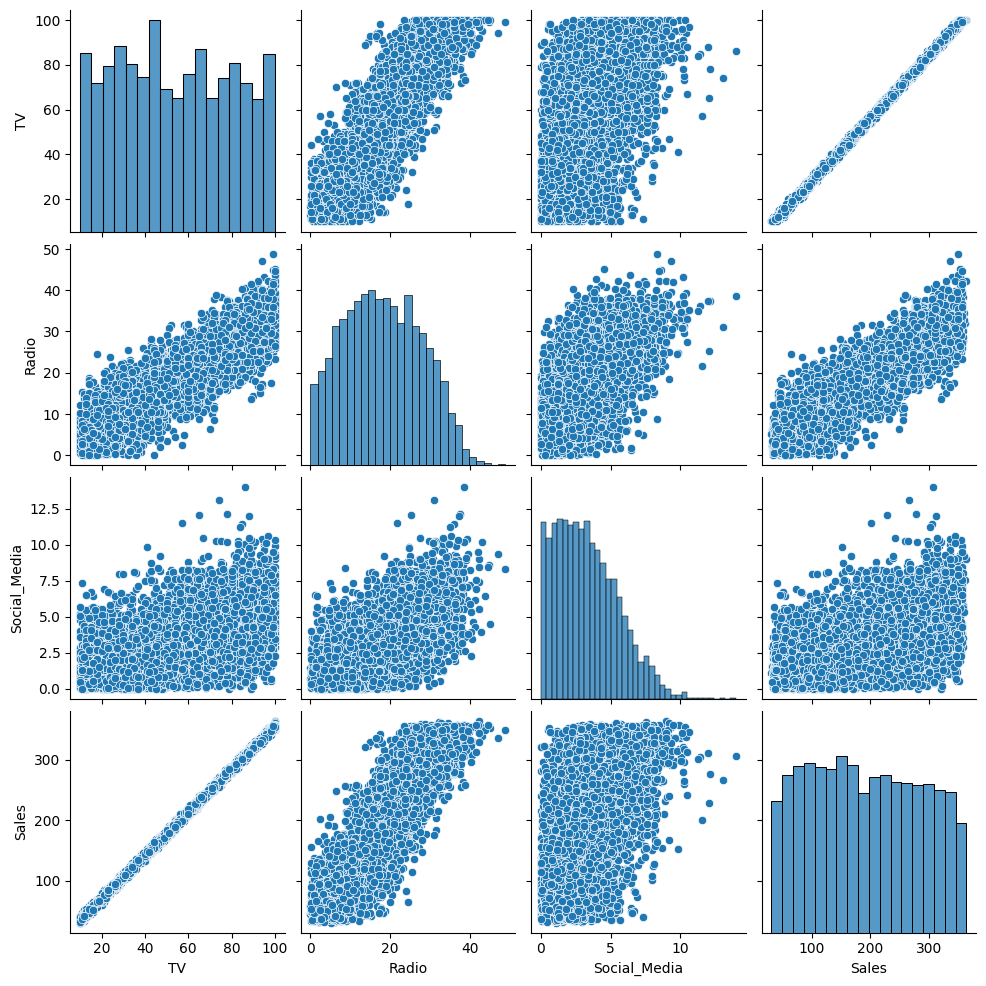

In [15]:
sns.pairplot(df)

### Step 2: Build and Fit Model / Sales ~ TV

In [16]:
# Defining Ordrinary Least Square (OLS) Formula

ols_data_TV = df[["Sales","TV"]]
ols_formula_TV = "Sales ~ TV"

In [17]:
# Create OLS Model

OLS_TV = ols(
    formula = ols_formula_TV,
    data = ols_data_TV
)

In [18]:
# Fit the Model

model_TV = OLS_TV.fit()

In [19]:
# Display Model Result

model_TV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:35:04   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Result Intepretation:

* R-Square 0.999 → Model explains 99.9% of the varieance, model has really high confidence
* p-value > significance level of 5% → result is statistically significant

### Linear Regression Formula:

* Sales (in millions) = -0.13 + 3.5 TV* (spending in millions)

Meaning 1 euros increase in TV Ad spending would increase 3.5 euros increase in Sales --> good return on investment

### Step 3: Model Assumption Check

To justify using simple linear regression, check that the four linear regression assumptions are not violated. These assumptions are:

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Check Assumption: Linearity
This can be done by plotting scatterplot of x,y values to confirm linearity shape

<Axes: xlabel='TV', ylabel='Sales'>

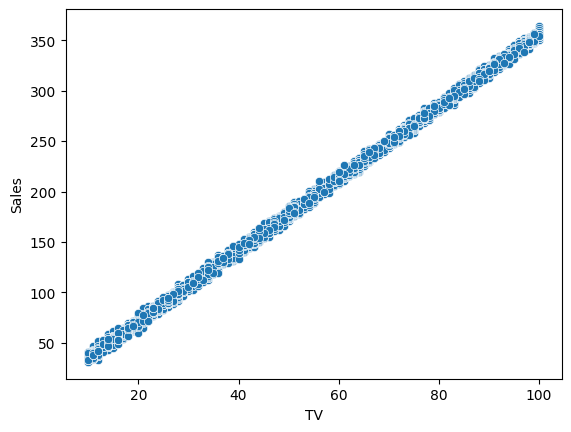

In [20]:
# create scatterplot

sns.scatterplot (
    x = ols_data_TV['TV'],
    y = ols_data_TV['Sales']
)

Intepretation: datapoints follow a straight line, suggest linearity (this was also observed in pairplot)

### Check Assumption: Independent Observation
Checked. Each row is independent marketing campaign.

### Check Assumption: Normality

To do this, we check if the residual values (model errors) follow a normal distribution.

### This can be confirmed via:

* Histogram of residual values
* QQPlot

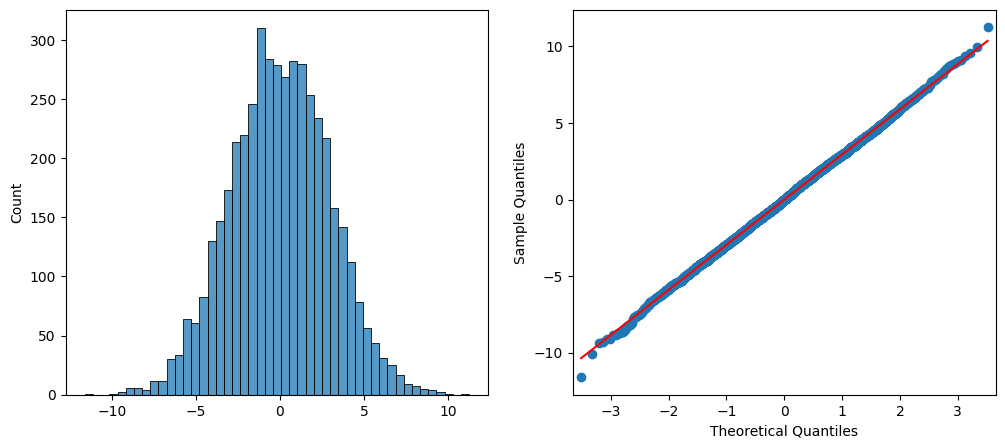

In [21]:
# Calculate residuals

residuals = model_TV.resid

# Create Plot

fig, axes = plt.subplots(1,2,figsize=(12,5))

# Put histogram in first plot
ax1 = sns.histplot(residuals,ax = axes[0])

# Place qqplot in 2nd plot
ax2 = sm.qqplot(residuals,line ="s", ax = axes[1])

### Check Assumption: Homoscedasticity

This assumption we check if the residual values are distributed evenly for all values of independent variable (X)

To do it, we plot a scatterplot of all residual values Y for all avaible predicted value based on X

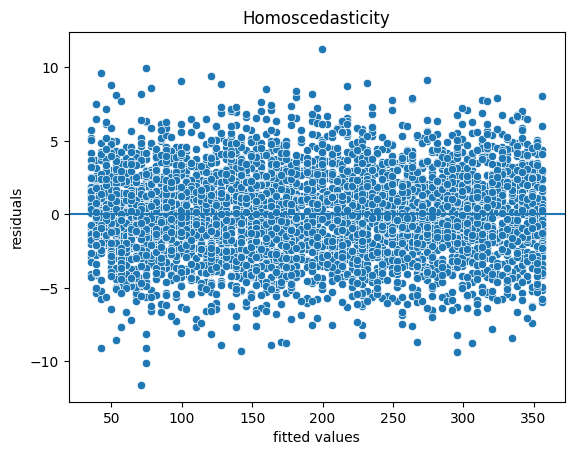

In [22]:
# Create Fitted Value (predicted value)

fitted_values = model_TV.predict(ols_data_TV["TV"])

# Create Scatter Plot

fig = sns.scatterplot (x= fitted_values, y = residuals)

fig.set_xlabel('fitted values')
fig.set_ylabel('residuals')
fig.set_title('Homoscedasticity')

# Add line 0
fig.axhline(0)

Intepretation: The residual values scattered evenly above and below line y = 0, accross all fitted values, suggesting homoscedasticity is not violated